<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src="attachment:image.png" alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---


## Tarea 04 – Aprendizaje automático

- **Fecha de Entrega:** 13 de noviembre de 2025, a las 23:59.
- **Fecha de publicación**: 30 de octubre de 2025.
- **Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 04 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

### 1.2 Pregunta de ciencia de datos

Esta tarea tendrá como objetivo crear un predictor que determine el éxito o fracaso de una expedición a distintas montañas del Himalayas según datos del montañista y de la expedición. Vamos a responder a la pregunta de qué tan bien pueden atributos como año, estación, montaña, edad del montañista, entre otros, predecir el éxito o fracaso de una expedición.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

[The Himalayan Database](https://www.himalayandatabase.com/) consiste en una colección de registros de expediciones en la cordillera del Himalaya. Esta contiene información detallada de las cimas más altas del mundo, junto con miles de expediciones realizadas desde 1905 hasta 2024 e información de cada uno de los/las montañistas que han participado en ellas. (El dataset que utilizaremos fue extraído desde: https://mavenanalytics.io/data-playground/himalayan-expeditions)

Descargue el archivo `Himalayan+Expeditions.zip` disponible en el repositorio del curso. Como puede ver, esta información está separada en varios archivos `.csv`. Deberá utilizar las herramientas aprendidas durante el curso para juntar esta información, procesarla y crear un predictor que determine el éxito de una subida.

**Recomendación**: Puede revisar el archivo `himalayan_data_dictionary.csv` para saber el significado de cada una de las columnas de la base de datos.

### 2.1 Librerías

Para esta tarea puede utilizar cualquiera de las librerías previamente utilizadas en el curso. Puede agregar otras si lo estima conveniente para el desarrollo de la Tarea.

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sklearn as sk
import os
from random import sample

## 3. Carga y limpieza (1 punto)

### 3.1 DataFrame unificado (0.2 pts)

Inspeccione los atributos de cada dataset y extraiga la siguiente información de ellos:

1. Información de las montañas:
    * ID de la cima (`peakid`)
    * Nombre común de la montaña (`pkname`)
    * Altura (m) (`heightm`)
    * Cantidad de expediciones exitosas (`success_exp`)
    * Cantidad de expediciones fallidas (`failed_exp`)

2. Información de las expediciones:
    * ID de la expedición (`expid`)
    * Año (`year`)
    * Estación del año (`season`)

3. Información de los montañistas:
    * ID del miembro (`membid`)
    * Sexo (`sex`)
    * Año de nacimiento (`yob`)
    * Nacionalidad (`citizen`)
    * Completó la expedición exitosamente (`msuccess`)

Genere un único DataFrame con todos estos atributos, donde cada fila represente el ascenso de un/a montañista en una expedición. (Ojo que esto no necesariamente significa que cada fila será una persona diferente: si una persona escaló dos cumbres distintas en dos expediciones, esta debería aparecer en su DataFrame como dos filas separadas.)


In [120]:
ENCODING = 'latin1' #con utf-8 arrojaba error


#Cargamos los dataframes solo con las columnas de interes y otras para unirlos 
cols_members = ['expid', 'peakid', 'sex', 'yob', 'citizen', 'msuccess', 'membid'] 
cols_exped = ['expid', 'peakid', 'year', 'season']
cols_peaks = ['peakid', 'pkname', 'heightm', 'success_exp', 'failed_exp']

df_members = pd.read_csv(os.path.join('data', 'members.csv'), 
                        encoding=ENCODING, 
                        usecols=cols_members)

df_exped = pd.read_csv(os.path.join('data', 'exped.csv'), 
                       encoding=ENCODING, 
                       usecols=cols_exped)


df_peaks = pd.read_csv(os.path.join('data', 'peaks_with_exp.csv'), 
                       encoding=ENCODING, 
                       usecols=cols_peaks)

dict_df = {
    'df_members': df_members,
    'df_exped': df_exped,
    'df_peaks': df_peaks
}

for name in dict_df:
    print("="*62)
    print(f'Resultado de {name} (primeras  filas)')
    display(dict_df[name].head())
print("="*62)

Resultado de df_members (primeras  filas)


,expid,membid,peakid,sex,yob,citizen,msuccess
0,AMAD01101,2,AMAD,M,1972.0,Australia,False
1,AMAD01101,1,AMAD,M,1968.0,Australia,False
2,AMAD01101,3,AMAD,M,1960.0,Australia,False
3,AMAD01101,4,AMAD,M,1966.0,Australia,False
4,AMAD01101,5,AMAD,F,1970.0,Australia,False


Resultado de df_exped (primeras  filas)


,expid,peakid,year,season
0,ANN260101,ANN2,1960,Spring
1,ANN269301,ANN2,1969,Autumn
2,ANN273101,ANN2,1973,Spring
3,ANN278301,ANN2,1978,Autumn
4,ANN279301,ANN2,1979,Autumn


Resultado de df_peaks (primeras  filas)


,peakid,pkname,heightm,failed_exp,success_exp
0,ACHN,Aichyn,6055,1,2
1,AMAD,Ama Dablam,6814,453,1123
2,AMOT,Amotsang,6393,2,1
3,AMPG,Amphu Gyabjen,5630,1,3
4,AMPH,Amphu I,6740,1,1


Antes de unir todos los dataframes, notar que la jerarquia de estos es `df_peaks` > `df_expid` > `df_members`. Distintos miembros asisten a una expedición y múltiples expediciones asisten a una cumbre.

Con eso en mente, unimos según la jerarquía

In [121]:
df_exped_peaks = pd.merge(df_exped, df_peaks, on='peakid', how='left')

#mantenemos las filas de los miembros, para no perderr registro de ninguno. Usando on=[expid, peakid] para no repetir ningun valor.
df_unificado = pd.merge(df_members, df_exped_peaks, on=['expid', 'peakid'], how='left')
filas_random = (df_unificado.sample(10))

In [122]:
display(filas_random.sort_index())

,expid,membid,peakid,sex,yob,citizen,msuccess,year,season,pkname,heightm,failed_exp,success_exp
4132,AMAD03307,9,AMAD,F,1951.0,Germany,True,2003,Autumn,Ama Dablam,6814,453,1123
22109,EVER10108,3,EVER,M,1979.0,S Korea,True,2010,Spring,Everest,8849,852,1495
25322,CHOY11328,2,CHOY,M,1959.0,Canada,True,2011,Autumn,Cho Oyu,8188,498,861
31046,EVER14168,1,EVER,M,1965.0,Japan,False,2014,Spring,Everest,8849,852,1495
32246,EVER15126,26,EVER,M,1971.0,Nepal,False,2015,Spring,Everest,8849,852,1495
36790,DHA117103,9,DHA1,M,1987.0,India,False,2017,Spring,Dhaulagiri I,8167,241,183
62622,CHOY96111,3,CHOY,M,1959.0,Italy,False,1996,Spring,Cho Oyu,8188,498,861
63226,CHOY98110,4,CHOY,M,1970.0,Netherlands,False,1998,Spring,Cho Oyu,8188,498,861
67560,EVER90303,13,EVER,M,1968.0,Japan,False,1990,Autumn,Everest,8849,852,1495
69375,EVER96112,14,EVER,M,1966.0,Germany,False,1996,Spring,Everest,8849,852,1495


### 3.2 Limpieza y transformación (0.2 pts)

Inspeccione y procese su DataFrame para generar uno nuevo llamado `clean_df`. En esta sección usted debe decidir si es necesario:

* Limpiar valores nulos, duplicados o inválidos.
* Imputar valores.
* Transformar tipos de columnas.

Justifique su procesamiento.

In [123]:
# respuestas
print("ℹ️ Información relevante para df_unificado ℹ️:\n")
display(df_unificado.info())

ℹ️ Información relevante para df_unificado ℹ️:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89089 entries, 0 to 89088
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   expid        89089 non-null  object 
 1   membid       89089 non-null  int64  
 2   peakid       89089 non-null  object 
 3   sex          89089 non-null  object 
 4   yob          83665 non-null  float64
 5   citizen      89082 non-null  object 
 6   msuccess     89089 non-null  bool   
 7   year         89089 non-null  int64  
 8   season       89089 non-null  object 
 9   pkname       89089 non-null  object 
 10  heightm      89089 non-null  int64  
 11  failed_exp   89089 non-null  int64  
 12  success_exp  89089 non-null  int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 8.2+ MB


None

In [124]:
yob_validos = 83665
total = 89089
yob_nan = abs(yob_validos - total)
print(f"En la columna yob (year of birth) hay {yob_nan} valores NaN ")

En la columna yob (year of birth) hay 5424 valores NaN 


In [125]:
df_unificado[df_unificado['yob'].isna()]

,expid,membid,peakid,sex,yob,citizen,msuccess,year,season,pkname,heightm,failed_exp,success_exp
448,EVER01131,26,EVER,M,NaN,China,True,2001,Spring,Everest,8849,852,1495
804,TILI01101,7,TILI,M,NaN,Nepal,True,2001,Spring,Tilicho,7134,59,31
805,TILI01101,5,TILI,M,NaN,Nepal,True,2001,Spring,Tilicho,7134,59,31
806,TILI01101,6,TILI,M,NaN,Nepal,True,2001,Spring,Tilicho,7134,59,31
847,AMAD01304,7,AMAD,M,NaN,Nepal,True,2001,Autumn,Ama Dablam,6814,453,1123
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89066,SISN73301,4,SISN,M,NaN,UK,False,1973,Autumn,Sisne Himal,5911,0,2
89070,GIMM39201,4,GIMM,M,NaN,Nepal,False,1939,Summer,Gimmigela Chuli,7350,8,3
89079,LNPS39201,9,LNPS,M,NaN,Nepal,False,1939,Summer,Langpo South,6857,0,2
89085,SURM74101,3,SURM,M,NaN,UK,False,1974,Spring,Surma-Sarovar North,6564,3,1


Para futuros análisis necesitaremos la columna de año de nacimiento, por lo que descartarla no es una opción. Llamaremos un nuevo `dataframe` como `df_clean`, el cual contendrá los datos limpios acorde a lo que necesitaremos.

In [126]:
df_clean = df_unificado.dropna().copy()
(df_clean.sample(10)).sort_index()

,expid,membid,peakid,sex,yob,citizen,msuccess,year,season,pkname,heightm,failed_exp,success_exp
1046,BARU01307,4,BARU,M,1965.0,Austria,False,2001,Autumn,Baruntse,7152,204,131
12161,EVER07154,3,EVER,M,1980.0,UK,True,2007,Spring,Everest,8849,852,1495
22071,EVER10112,1,EVER,M,1957.0,Colombia,False,2010,Spring,Everest,8849,852,1495
42542,AMAD19102,2,AMAD,M,1959.0,USA,False,2019,Spring,Ama Dablam,6814,453,1123
54914,MANA23317,1,MANA,M,1973.0,Nepal,True,2023,Autumn,Manaslu,8163,318,457
65945,EVER82301,10,EVER,M,1948.0,Spain,False,1982,Autumn,Everest,8849,852,1495
68040,EVER92102,4,EVER,F,1956.0,Belgium,True,1992,Spring,Everest,8849,852,1495
70737,GAUR80301,4,GAUR,M,1957.0,Japan,False,1980,Autumn,Gaurishankar,7135,27,6
72033,KANG88102,3,KANG,M,1956.0,Spain,False,1988,Spring,Kangchenjunga,8586,77,127
86139,EVER00303,2,EVER,M,1963.0,S Korea,False,2000,Autumn,Everest,8849,852,1495


In [127]:
#revisamos valores duplicados
total_duplicados = df_clean.duplicated().sum()
total_duplicados

np.int64(0)

Para nuestro agrado, no contamos con entradas duplicadas.

In [128]:
# Cambios de tipo de dato sobre columnas
df_clean['sex'] = df_clean['sex'].astype('category')
df_clean['msuccess'] = df_clean['msuccess'].astype('category')
df_clean['season'] = df_clean['season'].astype('category')
df_clean['yob'] = df_clean['yob'].astype('int')
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83665 entries, 0 to 89088
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   expid        83665 non-null  object  
 1   membid       83665 non-null  int64   
 2   peakid       83665 non-null  object  
 3   sex          83665 non-null  category
 4   yob          83665 non-null  int64   
 5   citizen      83665 non-null  object  
 6   msuccess     83665 non-null  category
 7   year         83665 non-null  int64   
 8   season       83665 non-null  category
 9   pkname       83665 non-null  object  
 10  heightm      83665 non-null  int64   
 11  failed_exp   83665 non-null  int64   
 12  success_exp  83665 non-null  int64   
dtypes: category(3), int64(6), object(4)
memory usage: 7.3+ MB


Notemos que la memoria RAM usada por el dataframe disminuyó, esto gracias a la implementación de columnas tipo categóricas.

### 3.2 Creación de nuevas columnas (0.6 pts)

Vamos a crear un par de columnas nuevas que nos ayudarán a hacer una análisis exploratorio del dataset.
Utilizando las columnas actuales, genere y agregue las siguientes columnas a su DataFrame:

* `age`: Edad del montañista a la fecha de la expedición.
* `peak_success_p`: Porcentaje de expediciones exitosas de la cima respectiva.

De ser necesario, aplique procesos de limpieza y transformación a estas columnas también (asegúrese de que todos los valores sean coherentes).

In [129]:
# 
df_clean['age'] = (df_clean['year'] - df_clean['yob']).astype(int)
df_clean.sample(5).sort_index()

,expid,membid,peakid,sex,yob,citizen,msuccess,year,season,pkname,heightm,failed_exp,success_exp,age
2874,POKR02302,2,POKR,M,1951,Nepal,False,2002,Autumn,Pokharkang,6372,3,4,51
15912,MAK208301,3,MAK2,M,1965,Slovenia,True,2008,Autumn,Makalu II,7678,24,24,43
17067,EVER09155,17,EVER,M,1973,UK,True,2009,Spring,Everest,8849,852,1495,36
27581,EVER13173,3,EVER,M,1975,Germany,True,2013,Spring,Everest,8849,852,1495,38
47658,DHA121302,16,DHA1,M,1985,USA,False,2021,Autumn,Dhaulagiri I,8167,241,183,36


In [130]:
filas_negativas = df_clean[df_clean['age'] < 0]
display(filas_negativas.sample(5).sort_index())
print(f"El total de edades inválidas es de {len(filas_negativas)} registros.")


,expid,membid,peakid,sex,yob,citizen,msuccess,year,season,pkname,heightm,failed_exp,success_exp,age
19375,KANG10101,5,KANG,M,1982,Nepal,True,1910,Spring,Kangchenjunga,8586,77,127,-72
48513,EVER22101,4,EVER,M,2000,Nepal,True,1922,Spring,Everest,8849,852,1495,-78
48525,EVER22101,10,EVER,M,1996,Nepal,True,1922,Spring,Everest,8849,852,1495,-74
53696,AMAD23320,5,AMAD,M,2024,USA,True,2023,Autumn,Ama Dablam,6814,453,1123,-1
55356,EVER24101,1,EVER,M,1995,Nepal,True,1924,Spring,Everest,8849,852,1495,-71


El total de edades inválidas es de 40 registros.


Como se obtuvieron 40 registros de edades negativas, lo cual no tiene sentido. Se deciden **eliminar las filas** que contengan dichos registros, probablemente fueron ingresados con un **error de typeo o similar**. Estos datos **no aportan** a nuestra investigación y si los manipularamos, estaríamos alterando los resultados objetivos de este trabajo.

In [131]:
df_clean = df_clean[df_clean['age'] >= 0]
round(df_clean.describe(), 2)

,membid,yob,year,heightm,failed_exp,success_exp,age
count,83625.00,83625.00,83625.00,83625.00,83625.00,83625.00,83625.00
mean,7.78,1966.32,2004.65,7934.52,421.07,741.57,38.33
std,8.40,16.13,14.58,839.99,314.44,598.39,10.77
min,1.00,1849.00,1905.00,5407.00,0.00,0.00,7.00
25%,2.00,1956.00,1996.00,7134.00,163.00,131.00,30.00
50%,5.00,1967.00,2008.00,8167.00,453.00,861.00,37.00
75%,10.00,1978.00,2016.00,8849.00,852.00,1495.00,45.00
max,99.00,2008.00,2024.00,8849.00,852.00,1495.00,156.00


Notemos que `df_clean` tiene las columnas:

- `success_exp`: Que es el número total de expediciones exitosas a esa cima (dada por `pkname`).

- `failed_exp`: Que es el número total de expediciones fallidas a esa cima.

Por lo que el **%** estará dado por `success_exp` / (`failed_exp` + `success_exp`).

In [132]:
total_exped = df_clean['success_exp'] + df_clean['failed_exp']
df_clean['peak_success_p'] = round((df_clean['success_exp'] / total_exped).fillna(0), 2)
df_clean.sample(5).sort_index()

,expid,membid,peakid,sex,yob,citizen,msuccess,year,season,pkname,heightm,failed_exp,success_exp,age,peak_success_p
5546,EVER04138,4,EVER,F,1968,USA,True,2004,Spring,Everest,8849,852,1495,36,0.64
31310,MANA14323,1,MANA,F,1963,Norway,True,2014,Autumn,Manaslu,8163,318,457,51,0.59
53405,AMAD23308,11,AMAD,M,1977,Lithuania,True,2023,Autumn,Ama Dablam,6814,453,1123,46,0.71
75961,MANA96301,4,MANA,M,1938,Japan,True,1996,Autumn,Manaslu,8163,318,457,58,0.59
82830,TENG99302,2,TENG,F,1938,Germany,False,1999,Autumn,Tengkoma,6215,5,8,61,0.62


## 4. EDA (2.5 puntos)

Con el dataset obtenido, responda las siguientes preguntas. Para cada una de ellas, realice al menos un gráfico que permita visualizar el comportamiento de su dataset.

a. **(0.5 pts)** ¿Cuántos ascensos exitosos y fallidos hay en su dataset? ¿A qué porcentaje del total corresponde cada categoría?

b. **(0.5 pts)** ¿Cómo se distribuyen las edades de los/las montañistas en la base de datos?

c. **(0.5 pts)** ¿Cómo se distribuye la cantidad de ascensos según estación del año? ¿Cuál es el porcentaje de éxito por estación? Muestre la cantidad de filas de ascensos exitosas y fallidas para cada estación.

d. **(0.5 pts)** ¿Cómo cambia la cantidad de ascensos en el tiempo? Muestre la cantidad de ascensos exitosos y fallidos por año.

e. **(0.5 pts)** ¿Existe una correlación entre el porcentaje de éxito de ascenso y la altura de una cumbre? Haga un scatterplot para todas las cumbres que hayan sido escaladas por al menos 10 expediciones en total (tanto fallidas como exitosas).

In [133]:
# a) Contamos los éxitos y fallos con sus porcentajes:
nro_exitos = df_clean['msuccess'].value_counts()
porc_exitos = df_clean['msuccess'].value_counts(normalize=True) * 100

display(nro_exitos)
display(porc_exitos)

msuccess
False    48365
True     35260
Name: count, dtype: int64

msuccess
False    57.835575
True     42.164425
Name: proportion, dtype: float64

In [134]:
#nos aseguramos de que todo tenga registro válido
df_clean[(df_clean['msuccess'] != True) & (df_clean['msuccess'] != False)]

,expid,membid,peakid,sex,yob,citizen,msuccess,year,season,pkname,heightm,failed_exp,success_exp,age,peak_success_p


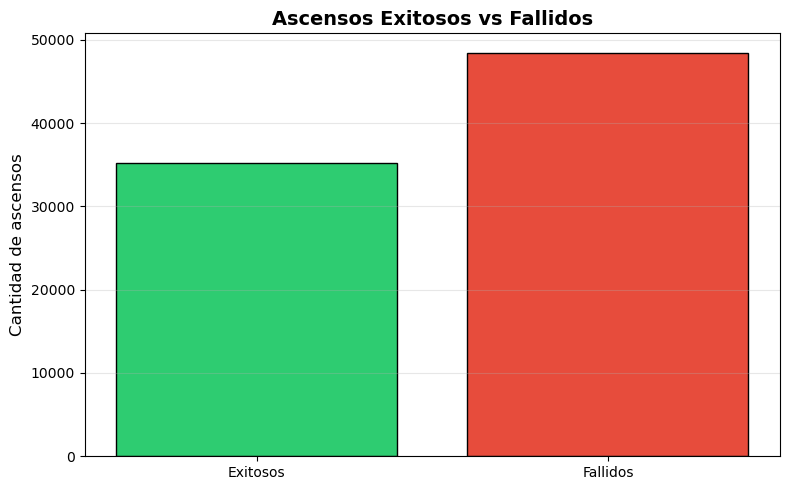

Escaladas exitosas: 35260 que corresponde al 42.16% del total
Escaladas fallidas: 48365 que corresponde al 57.84% del total


In [135]:
plt.figure(figsize=(8, 5))
orden = [True, False]

plt.bar(['Exitosos', 'Fallidos'], nro_exitos.reindex(orden), color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.ylabel('Cantidad de ascensos', fontsize=12)
plt.title('Ascensos Exitosos vs Fallidos', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


print(f"Escaladas exitosas: {nro_exitos[True]} que corresponde al {round(porc_exitos[True], 2)}% del total")
print(f"Escaladas fallidas: {nro_exitos[False]} que corresponde al {round(porc_exitos[False], 2)}% del total")


In [136]:
# b) Antes de graficar las distribuciones de edades. Revisamos eventuales outliers:
edades_outliers = (df_clean[df_clean['age'] >= 100])
display(edades_outliers.sample(5).sort_index())
print(f"Hay {len(edades_outliers)} valores tentativos a imputar dado que tienen una edad mayor a 100 años")


,expid,membid,peakid,sex,yob,citizen,msuccess,year,season,pkname,heightm,failed_exp,success_exp,age,peak_success_p
78829,EVER21101,1,EVER,M,1883,UK,False,2021,Spring,Everest,8849,852,1495,138,0.64
82937,EVER22101,5,EVER,M,1875,UK,False,2022,Spring,Everest,8849,852,1495,147,0.64
82939,EVER22101,6,EVER,M,1886,UK,False,2022,Spring,Everest,8849,852,1495,136,0.64
82947,EVER22101,9,EVER,M,1890,UK,False,2022,Spring,Everest,8849,852,1495,132,0.64
82955,EVER24101,3,EVER,M,1896,UK,False,2024,Spring,Everest,8849,852,1495,128,0.64


Hay 34 valores tentativos a imputar dado que tienen una edad mayor a 100 años


In [137]:
#limpiamos el dataset para no tener medidas estadisticas falsas
df_clean = df_clean[(df_clean['age'] >= 0) & (df_clean['age'] <= 100)]

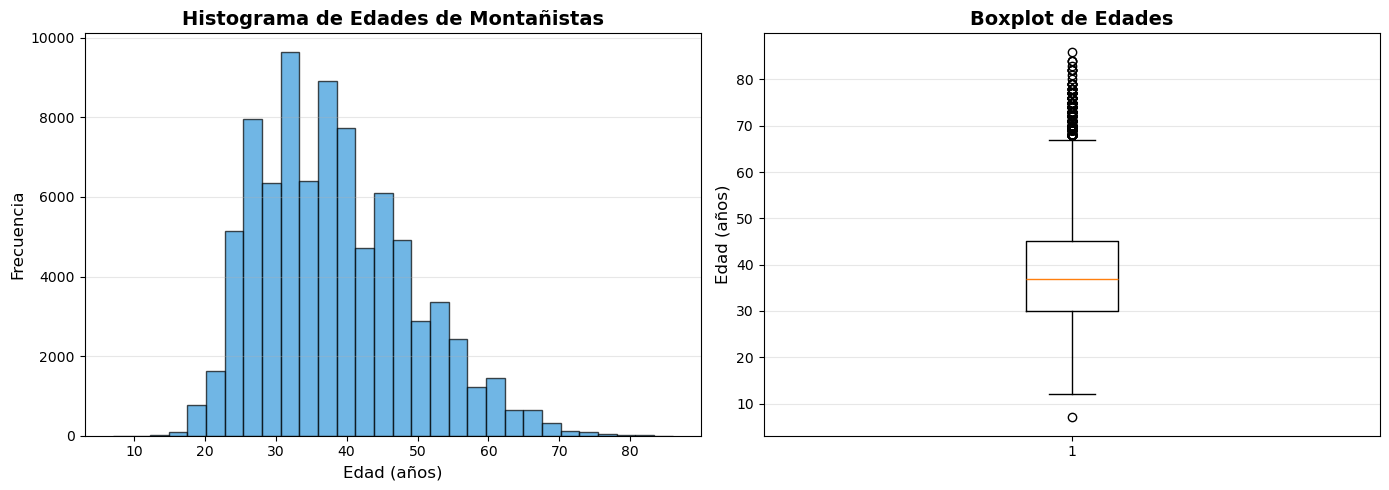

Edad promedio: 38 años
Edad mínima: 7 años
Edad máxima: 86 años
Mediana de edad: 37.0 años


In [138]:
# b) Distribución de edades

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['age'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Edad (años)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Histograma de Edades de Montañistas', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].boxplot(df_clean['age'], vert=True)
axes[1].set_ylabel('Edad (años)', fontsize=12)
axes[1].set_title('Boxplot de Edades', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Edad promedio: {round(df_clean['age'].mean(), )} años")
print(f"Edad mínima: {df_clean['age'].min()} años")
print(f"Edad máxima: {df_clean['age'].max()} años")
print(f"Mediana de edad: {df_clean['age'].median()} años")



Luego de **validar** los datos, podemos evidenciar que la tendencia de edad de los montañistas es cercana a las personas naciadas en 1987 (2025 - (edad promedio = 38)). Es crucial saber que como no somos expertos del área, estas medidas son generadas en base a filtros objetivos y se intenta evitar a toda costa eventuales sesgos.

In [139]:
# c)
total_verano = (df_clean['season'] == 'Summer').sum()
total_invierno = (df_clean['season'] == 'Winter').sum()
total_otoño = (df_clean['season'] == 'Autumn').sum()
total_primavera = (df_clean['season'] == 'Spring').sum()
print(f"Existen {total_verano} ascensos totales durante la temporada de verano, {total_invierno} en invierno, {total_otoño}" +
      f" en otoño y {total_primavera} en primavera.")

Existen 645 ascensos totales durante la temporada de verano, 2125 en invierno, 39530 en otoño y 41291 en primavera.



Tabla de contingencia (estación vs exito):


msuccess,False,True,All
season,,,
Autumn,23924,15606,39530
Spring,22304,18987,41291
Summer,469,176,645
Winter,1634,491,2125
All,48331,35260,83591



Porcentaje de éxito por estación:


msuccess,False,True
season,,
Autumn,60.52,39.48
Spring,54.02,45.98
Summer,72.71,27.29
Winter,76.89,23.11


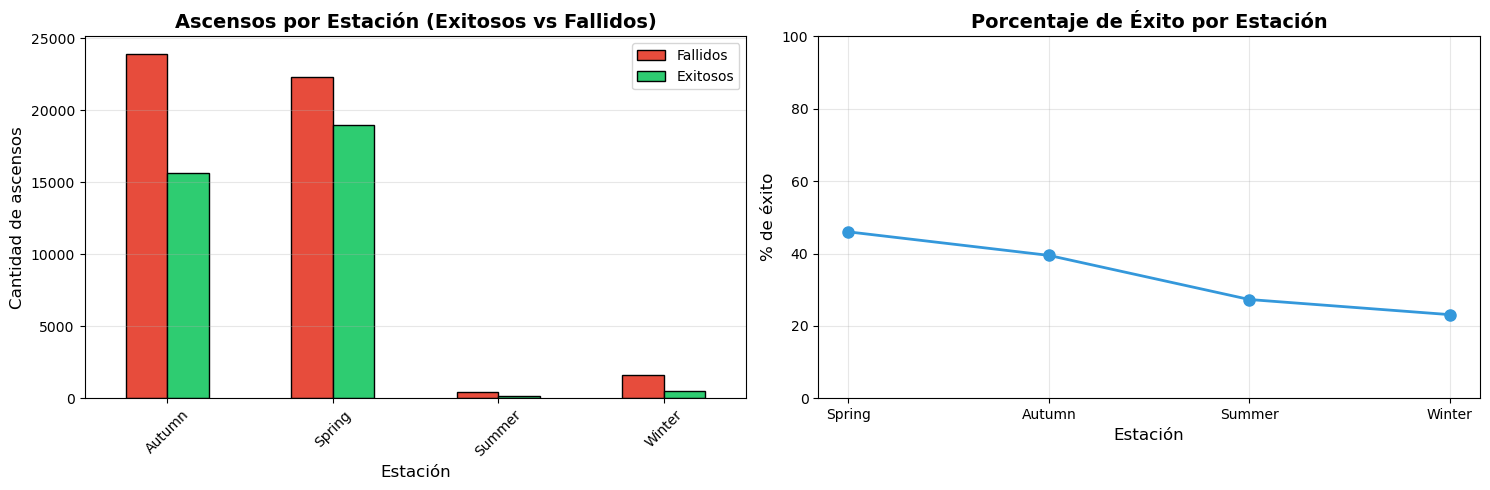

In [140]:
season_success = pd.crosstab(df_clean['season'], df_clean['msuccess'], margins=True)
print("\nTabla de contingencia (estación vs exito):")
display(season_success)

#porcentaje de éxito por estación, se usa una crosstab para ver la relacion entre season y msucces
season_pct = pd.crosstab(df_clean['season'], df_clean['msuccess'], normalize='index') * 100
print("\nPorcentaje de éxito por estación:")
display(season_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#gráfico de barras apiladas
season_counts = pd.crosstab(df_clean['season'], df_clean['msuccess'])
season_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_xlabel('Estación', fontsize=12)
axes[0].set_ylabel('Cantidad de ascensos', fontsize=12)
axes[0].set_title('Ascensos por Estación (Exitosos vs Fallidos)', fontsize=14, fontweight='bold')
axes[0].legend(['Fallidos', 'Exitosos'], loc='upper right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

#gráfico lineal con porcentaje de éxito
season_success_pct = pd.crosstab(df_clean['season'], df_clean['msuccess'], normalize='index')[True] * 100
season_success_pct = season_success_pct.sort_values(ascending=False)
axes[1].plot(season_success_pct.index, season_success_pct.values, marker='o', linewidth=2, markersize=8, color='#3498db')
axes[1].set_xlabel('Estación', fontsize=12)
axes[1].set_ylabel('% de éxito', fontsize=12)
axes[1].set_title('Porcentaje de Éxito por Estación', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 100])

plt.tight_layout()
plt.show()


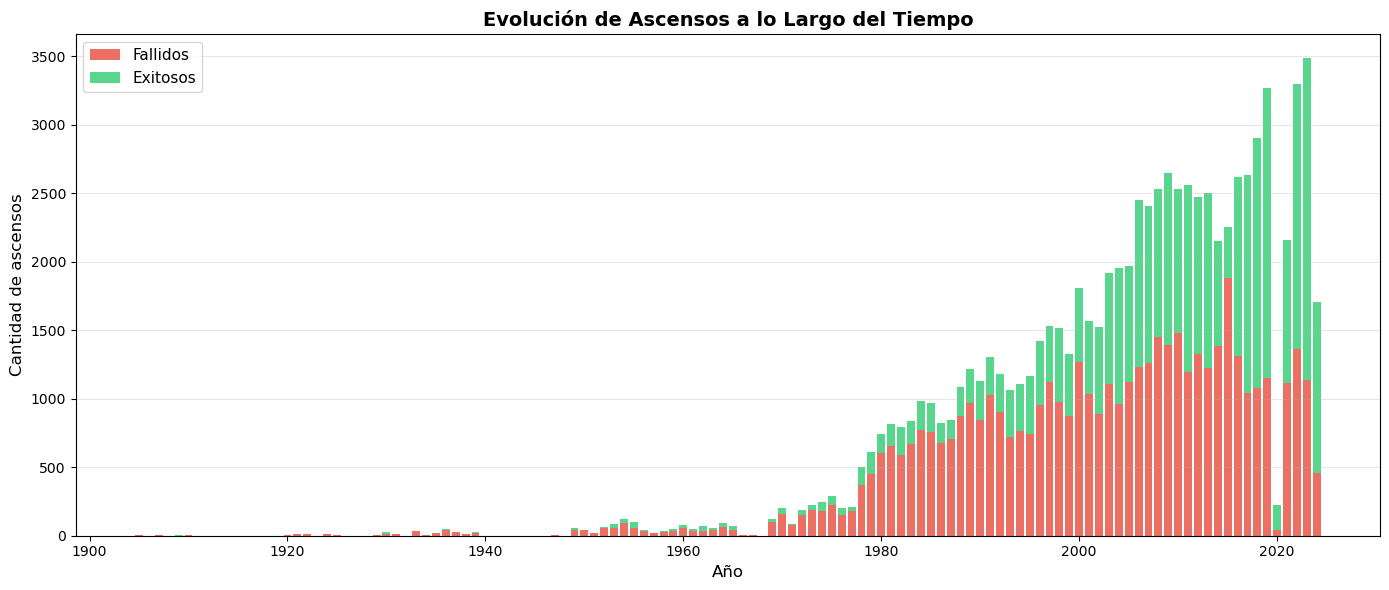

In [141]:
ascensos_por_ano = pd.crosstab(df_clean['year'], df_clean['msuccess'])

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(ascensos_por_ano.index, ascensos_por_ano[False], label='Fallidos', color='#e74c3c', alpha=0.8)
ax.bar(ascensos_por_ano.index, ascensos_por_ano[True], bottom=ascensos_por_ano[False], 
       label='Exitosos', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Cantidad de ascensos', fontsize=12)
ax.set_title('Evolución de Ascensos a lo Largo del Tiempo', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n")

Los resultados demuestran notablemente un aumento en los ascensos a montes a lo largo de los años.

## 5. Predictor (2.5 puntos)

Ahora veremos si la información que tenemos nos permite predecir el éxito de un ascenso por alguna persona en particular. Primero, defina su **X** (matriz de atributos) e **y** (etiqueta a predecir) de la siguiente manera:

* **X**: `age`, `sex`, `citizen`, `season`, `heightm`, `year`, `success_exp`, `failed_exp`
* **y**: `msuccess`

Luego, realice los pasos a continuación:

**5.1 Codificación y normalización (1 pto)**
* Codifique todas las columnas categóricas, de manera que su matriz **X** solo tenga valores numéricos.
* Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30.
* Normalice sus matrices de atributos. Justifique su método de normalización.

**5.2 Creación y entrenamiento de modelos (1 pto)**
* Cree y entrene los siguientes modelos:
    * Un clasificador KNN
    * Un árbol de decisión
    * Un clasificador de regresión logística
    * Un clasificador random forest **(Opcional)**

    Explique qué hiperparámetros utilizó para la creación de cada uno de ellos y qué valores le asignó.

* Finalmente, evalúe todos sus modelos con el set de testeo. Para cada uno, muestre
    * Accuracy
    * Precisión
    * Recall
    * Matriz de confusión

**5.3 Análisis de resultados (0.5 pts)**

Interprete, analice y comente sus resultados. 
* ¿Qué tendencias puede observar? ¿Se diferencian de alguna forma las predicciones entre un modelo y otro? 
* ¿Fue posible construir un predictor efectivo? Justique.



In [142]:
# respuestas

Respuestas: